In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf

import sys
import pickle

sys.path.append('..')
sys.path.append('../..')

from src.Environment.environment_v4 import MyModelSelectionEnv
from src.utils import *
from src.metrics import *
from src.Components.data_processing import data_process
from sklearn.model_selection import train_test_split

2024-04-29 05:48:04.254543: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-29 05:48:04.254644: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-29 05:48:04.291779: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-04-29 05:48:04.387484: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-04-29 05:48:05.811044: W tensorflow/compiler/tf2

In [2]:
import tf_agents.bandits.agents as bandit_agents
from tf_agents.metrics import tf_metrics
from tf_agents.trajectories import time_step as ts
from tf_agents.drivers import dynamic_step_driver
from tf_agents.environments import tf_py_environment
from tf_agents.networks import q_network
from tf_agents.bandits.replay_buffers import bandit_replay_buffer
from tf_agents.metrics import export_utils
from tf_agents.policies import policy_saver
from tf_agents.agents.random.random_agent import RandomAgent

### Importing Data and Setting Up the Environment

In [3]:
min_length = 0
max_length = 140000

filepath = '../datasets/ECG/MBA_ECG14046_data_0.out'
column_name = ['value', 'anomaly']
df = pd.read_csv(filepath, header=None, names=column_name).dropna()
df = df.iloc[min_length:max_length]
data_np = df.to_numpy()

name = filepath.split('/')[-1]

data = data_np[min_length:max_length,0].astype(float)
label = data_np[min_length:max_length,1].astype(int)

In [4]:
df1 = df.iloc[15000:16000]
df2 = df.iloc[70000:73000]
df3 = df.iloc[85000:86150]

train_data = pd.concat([df1, df2, df3])

In [5]:
train_data

,value,anomaly
15000,-1.70,0.0
15001,-1.98,0.0
15002,-1.24,0.0
15003,-1.00,0.0
15004,-0.39,0.0
...,...,...
86145,0.22,0.0
86146,0.30,0.0
86147,0.30,0.0
86148,0.30,0.0


In [6]:
test_data = df.iloc[35000:141000]

list_threshold = [0.63, 0.75, 0.78, 0.68, 0.79, 0.72, 0.5, 0.26]

list_gtruth_test = test_data[['anomaly']].values.reshape(-1, 1)

list_gtruth_train = train_data[['anomaly']].values.reshape(-1, 1)

model_keys = ['IF', 'S2G', 'norma', 'PCA', 'SAND_OFF', 'POLY', 'OCSVM']

### Preparing the Parameters

In [7]:
import pickle
import json

with open(f'../data/ecg14046_0_35k_140k.pkl', 'rb') as file:
    loaded_test_feats = pickle.load(file)

with open('../data/ecg14046_0_scores_dict_tsb_full.json', 'r') as file:
    loaded_score_dict = json.load(file)

with open('../data/features_ecg14046_train_10k_20k.pkl', 'rb') as file:
    loaded_train_feat1 = pickle.load(file)

with open('../data/features_ecg14046_0_50k_80k.pkl', 'rb') as file:
    loaded_train_feat2 = pickle.load(file)

with open('../data/pred_labels_ecg14046_0_full.json', 'r') as file:
    y_pred_ecg805 = json.load(file)

In [8]:
loaded_score_dict['OCSVM'] = pd.Series(loaded_score_dict['OCSVM']).ewm(alpha=0.4).mean().to_list()
loaded_score_dict['AE'] = pd.Series(loaded_score_dict['AE']).ewm(alpha=0.4).mean().to_list()

In [9]:
new_train_feats = []

for element in loaded_train_feat1:
    element.drop('var_0__length', axis=1, inplace=True)

for element in loaded_train_feat2:
    element.drop('var_0__length', axis=1, inplace=True)

for element in loaded_test_feats:
    element.drop('var_0__length', axis=1, inplace=True)

In [10]:
sub_feat1 = loaded_train_feat1[5000:6000]
sub_feat2 = loaded_train_feat2[20000:23000]
sub_feat3 = loaded_test_feats[50000:51500]

loaded_train_feats = sub_feat1 + sub_feat2 + sub_feat3

In [11]:
len(loaded_train_feats)

5500

In [12]:
def list_of_list_slicer(listol, slices):

    n = len(slices)

    sliced_listol = []

    for sublist in listol:

        sub_slices = []

        for slice in slices:
            sub_slices.extend(sublist[slice[0]:slice[1]])
        
        sliced_listol.append(sub_slices)

    return sliced_listol

In [13]:
score_list = [sublist for keys, sublist in loaded_score_dict.items() if keys in model_keys]
pred_list = [sublist for keys, sublist in y_pred_ecg805.items() if keys in model_keys]
slices = [[15000, 16051], [70050, 73051], [85050, 86150]]

In [14]:
score_list_train = list_of_list_slicer(score_list, slices)
pred_list_train = list_of_list_slicer(pred_list, slices)

In [15]:
import math

math.ceil((100-1)/2)

50

In [16]:
for item in score_list_train:
    print(len(item))

5152
5152
5152
5152
5152
5152
5152


In [17]:
score_list_test = [sublist[35000:140100] for keys, sublist in loaded_score_dict.items() if keys in model_keys]
pred_list_test = [sublist[35000:140100] for keys, sublist in y_pred_ecg805.items() if keys in model_keys]

In [18]:
import random

order_list = [i for i in range(len(loaded_train_feats) + 150)]

combined_train_list = list(zip(order_list, loaded_train_feats, list_gtruth_train, *score_list_train))
random.shuffle(combined_train_list)
shuffled_order, shuffled_train_feats, shuffled_train_gtruth, *shuffled_score_train_lol = zip(*combined_train_list)
shuffled_score_train = [list(sublist) for sublist in shuffled_score_train_lol]

In [19]:
shuffled_pred_train = []
for predder in pred_list_train:
    shupre = [predder[i] for i in shuffled_order]
    shuffled_pred_train.append(shupre)

In [20]:
len(shuffled_score_train[0])

5150

In [21]:
# Shuffle Checker

predder = []
shuffled_t = shuffled_pred_train[7]
not_shuff = pred_list_train[7]
for i, shuff in enumerate(shuffled_order[0:9900]):
    predder.append(shuffled_t[i] == not_shuff[shuff])

preddnp = np.array(predder)
vval, ccont = np.unique(preddnp, return_counts=True)
print(vval, ccont)

IndexError: list index out of range

In [21]:
train_env = MyModelSelectionEnv(train_data, list_thresholds=list_threshold, list_gtruth=shuffled_train_gtruth, subsequence=shuffled_train_feats, list_predicted_score=shuffled_score_train, list_predicted_label = shuffled_pred_train)
train_environment = tf_py_environment.TFPyEnvironment(train_env) # Converts the PyEnvironment to TFEnvironment

In [22]:
action_spec = train_environment.action_spec()
observation_spec = train_environment.time_step_spec().observation

EPSILON = 0.1
LAYERS = (50, 50, 50)
LR = 0.005

# TRAINING_LOOPS = 500
steps_per_loop = 1
async_steps_per_loop = 1

network = q_network.QNetwork(
          input_tensor_spec=observation_spec,
          action_spec=action_spec,
          fc_layer_params=LAYERS,
      )

In [23]:

eps_agent = bandit_agents.neural_epsilon_greedy_agent.NeuralEpsilonGreedyAgent(action_spec=train_environment.action_spec(), time_step_spec=train_environment.time_step_spec(), reward_network=network, optimizer=tf.compat.v1.train.AdamOptimizer(learning_rate=LR),
        epsilon=EPSILON,
        emit_policy_info='predicted_rewards_mean',
        info_fields_to_inherit_from_greedy=['predicted_rewards_mean'])

eps_agent.initialize()

### Replay Buffers and Drivers

In [24]:
data_spec = eps_agent.policy.trajectory_spec

In [25]:
def get_replay_buffer(
    data_spec, batch_size, steps_per_loop, async_steps_per_loop
):
  """Return a `TFUniformReplayBuffer` for the given `agent`."""
  return bandit_replay_buffer.BanditReplayBuffer(
      data_spec=data_spec,
      batch_size=batch_size,
      max_length=steps_per_loop * async_steps_per_loop,
  )

In [26]:
replay_buffer = get_replay_buffer(
      data_spec, train_environment.batch_size, steps_per_loop, async_steps_per_loop
  )

In [27]:
# Observers

step_metric = tf_metrics.EnvironmentSteps()
metrics = [
      tf_metrics.NumberOfEpisodes(), # Counts the number of episodes in the environment
      tf_metrics.AverageEpisodeLengthMetric(batch_size=1),   # Metric to compute the average episode length
      tf_metrics.AverageReturnMetric(batch_size=1) # Metric to compute the average return
  ]

add_batch_fn = replay_buffer.add_batch # Adds a batch of items on the replay buffer

observers = [add_batch_fn, step_metric] + metrics # List of observers for the driver

In [28]:
driver = dynamic_step_driver.DynamicStepDriver(
      env=train_environment,
      policy=eps_agent.collect_policy,
      num_steps=steps_per_loop * train_environment.batch_size,
      observers=observers,
  )

In [29]:
# Replay Buffer Values

"""
    The .as_dataset method creates and returns a dataset as entries from the buffer.

    A single entry from the dataset is the result of the following pipeline:

    - Sample sequences from the underlying data store
    - (Optional) Process them with 'sequence_preprocess_fn'
    - (Optional) Split them into subsequences of length num_steps
    - (Optional) Batch them into batches of size 'sample_batch_size'

    In practice, this pipeline is executed in parallel as much as possible if num_parallel_calls != 1.

    
"""

dataset_it = iter(
        replay_buffer.as_dataset(
            sample_batch_size=1,
            num_steps=1,
            single_deterministic_pass=True,
        )
    )

In [30]:
def training_loop(train_step, metrics):
 
    driver.run()
     
    batch_size = driver.env.batch_size
    dataset_it = iter(
        replay_buffer.as_dataset(
            sample_batch_size=batch_size,
            num_steps=1,
            single_deterministic_pass=True,
        )
    )

    meter = driver.observers[1:]
    for batch_id in range(async_steps_per_loop):
      experience, unused_buffer_info = dataset_it.get_next()
      loss_info = eps_agent.train(experience)
      print(loss_info)

      export_utils.export_metrics(
          step=train_step * async_steps_per_loop + batch_id,
          metrics=meter,
          loss_info=loss_info,
      )

    replay_buffer.clear()

In [31]:
for i in range(1, 5000):

    training_loop(train_step=i, metrics=metrics)

Step: 1, label: 0
LossInfo(loss=<tf.Tensor: shape=(), dtype=float32, numpy=0.052834377>, extra=())
Step: 2, label: 0
LossInfo(loss=<tf.Tensor: shape=(), dtype=float32, numpy=0.14409025>, extra=())
Step: 3, label: 0
LossInfo(loss=<tf.Tensor: shape=(), dtype=float32, numpy=11.289659>, extra=())
Step: 4, label: 0
LossInfo(loss=<tf.Tensor: shape=(), dtype=float32, numpy=0.08654273>, extra=())
Step: 5, label: 0
LossInfo(loss=<tf.Tensor: shape=(), dtype=float32, numpy=0.014442427>, extra=())
Step: 6, label: 0
LossInfo(loss=<tf.Tensor: shape=(), dtype=float32, numpy=0.009747099>, extra=())
Step: 7, label: 1
LossInfo(loss=<tf.Tensor: shape=(), dtype=float32, numpy=3.0292459>, extra=())
Step: 8, label: 1
LossInfo(loss=<tf.Tensor: shape=(), dtype=float32, numpy=10.082732>, extra=())
Step: 9, label: 0
LossInfo(loss=<tf.Tensor: shape=(), dtype=float32, numpy=0.054646023>, extra=())
Step: 10, label: 0
LossInfo(loss=<tf.Tensor: shape=(), dtype=float32, numpy=0.061231647>, extra=())
Step: 11, label: 

In [32]:
policy = eps_agent.policy

### Evaluating the Policy

In [47]:
test_data = test_data.reset_index()
test_data

,level_0,index,value,anomaly
0,0,35000,0.00,0.0
1,1,35001,0.00,0.0
2,2,35002,-0.01,0.0
3,3,35003,0.00,0.0
4,4,35004,-0.02,0.0
...,...,...,...,...
104995,104995,139995,0.04,0.0
104996,104996,139996,0.04,0.0
104997,104997,139997,0.02,0.0
104998,104998,139998,0.02,0.0


In [18]:
test_env = MyModelSelectionEnv(test_data, list_thresholds=list_threshold, list_gtruth=list_gtruth_test, subsequence=loaded_test_feats, list_predicted_score=score_list_test, list_predicted_label=pred_list_test)
test_environment = tf_py_environment.TFPyEnvironment(test_env) # Converts the PyEnvironment to TFEnvironment

In [ ]:
# Trained Policy Steps in Test Environment

act = 0
policy_state = policy.get_initial_state(batch_size=1)
act_list = []
score_list = []
subseq = test_env.subsequences
test_end = 100000
label_list = []

aa = test_environment.reset()

for step in range(test_end):

    time_step = test_environment.step(act)
    policy_return = policy.action(time_step, policy_state)
    act = policy_return.action.numpy()
    _, label, scr = test_env._apply_action(act[0])
    label_list.append(label)
    score_list.append(scr)
    print(test_env.pointer)
    policy_state = policy_return.state
    act_list.append(act)

    if step % 20000 == 0:
        filename = f'../data/data_{step+1}.pkl'
        save_dict = {'score': score_list, 'label': label_list, 'action': act_list}
        with open(filename, 'wb') as file:
            pickle.dump(save_dict, file)

In [31]:
filename = f'../data/data_80001.pkl'

with open(filename, 'rb') as file:
    loaded_dict = pickle.load(file)

EOFError: Ran out of input

In [ ]:
score_np = np.array(score_list)
label_np = np.array(label_list)
uni_val, uni_counts = np.unique(label_np, return_counts=True)
print(uni_val, uni_counts)
print(test_data['anomaly'].value_counts())

[0 1] [28066 11782]
anomaly
0.0    28484
1.0    11516
Name: count, dtype: int64


In [ ]:
test_end = 105000
sample_gtruth = test_data['anomaly'].iloc[50:test_end+50]
gtruth_np = sample_gtruth.to_numpy()
print(gtruth_np.shape, score_np.shape)
rg_pr, rg_rc, rg_f1, rg_prauc, adjusted_y_pred = adjusted_precision_recall_f1_auc(gtruth_np, score_np)
print(f'Model: MAB Neural Epsilon Greedy Point Adjusted F1: {rg_f1:.4f}, Point Adjusted AUCpr: {rg_prauc:.4f}')

(39848,) (39848,)
Model: MAB Neural Epsilon Greedy Point Adjusted F1: 0.9390, Point Adjusted AUCpr: 0.9541


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

prec = precision_score(sample_gtruth, label_np)
recall = recall_score(sample_gtruth, label_np)
f1 = f1_score(sample_gtruth, label_np)
rock = roc_auc_score(sample_gtruth, score_np)

print(f'Precision Score: {prec:.4f}  Recall: {recall:.4f}  f1_score: {f1:.4f} roc_auc: {rock}')

Precision Score: 0.8959  Recall: 0.9243  f1_score: 0.9099 roc_auc: 0.9084412964993197


In [ ]:
gtruth_base = test_data['anomaly'].iloc[0:105000].to_numpy()

for model, scr in loaded_score_dict.items():
    sample_scr = np.array(scr[35000:140000])
    rg_pr, rg_rc, rg_f1, rg_prauc, adjusted_y_pred = adjusted_precision_recall_f1_auc(gtruth_base, sample_scr)
    print(f'Model: {model} Point Adjusted F1: {rg_f1:.4f}, Point Adjusted AUCpr: {rg_prauc:.4f}')

Model: IF Point Adjusted F1: 0.8922, Point Adjusted AUCpr: 0.9025
Model: S2G Point Adjusted F1: 0.9087, Point Adjusted AUCpr: 0.9089
Model: norma Point Adjusted F1: 0.9376, Point Adjusted AUCpr: 0.9482
Model: PCA Point Adjusted F1: 0.8029, Point Adjusted AUCpr: 0.7981
Model: SAND_OFF Point Adjusted F1: 0.9340, Point Adjusted AUCpr: 0.9519
Model: POLY Point Adjusted F1: 0.7688, Point Adjusted AUCpr: 0.7266
Model: OCSVM Point Adjusted F1: 0.8432, Point Adjusted AUCpr: 0.9119
Model: AE Point Adjusted F1: 0.9906, Point Adjusted AUCpr: 0.9892


In [ ]:
gtruth_base = test_data['anomaly'].iloc[0:105000].to_numpy()

for i, label in enumerate(pred_list_test):
    prec = precision_score(gtruth_base, label)
    recall = recall_score(gtruth_base, label)
    f1 = f1_score(gtruth_base, label)

    print(f'Model {i}: Precision Score: {prec:.4f}  Recall: {recall:.4f}  f1_score: {f1:.4f}')

Model 0: Precision Score: 0.8036  Recall: 0.9738  f1_score: 0.8806
Model 1: Precision Score: 0.8477  Recall: 0.9673  f1_score: 0.9035
Model 2: Precision Score: 0.9207  Recall: 0.9346  f1_score: 0.9276
Model 3: Precision Score: 0.6613  Recall: 0.9804  f1_score: 0.7899
Model 4: Precision Score: 0.9025  Recall: 0.9673  f1_score: 0.9338
Model 5: Precision Score: 0.6276  Recall: 0.9804  f1_score: 0.7653
Model 6: Precision Score: 0.8649  Recall: 0.8235  f1_score: 0.8437


In [ ]:
act_np = np.array(act_list)
uniq_act, uniq_count = np.unique(act_np, return_counts=True)
print(uniq_act, uniq_count)

[0 1 2 3 4 5 6] [  604   582 36285   562   741   515   559]


In [ ]:
model_keys = ['IF', 'S2G', 'norma', 'PCA', 'SAND_OFF', 'POLY', 'OCSVM', 'AE']

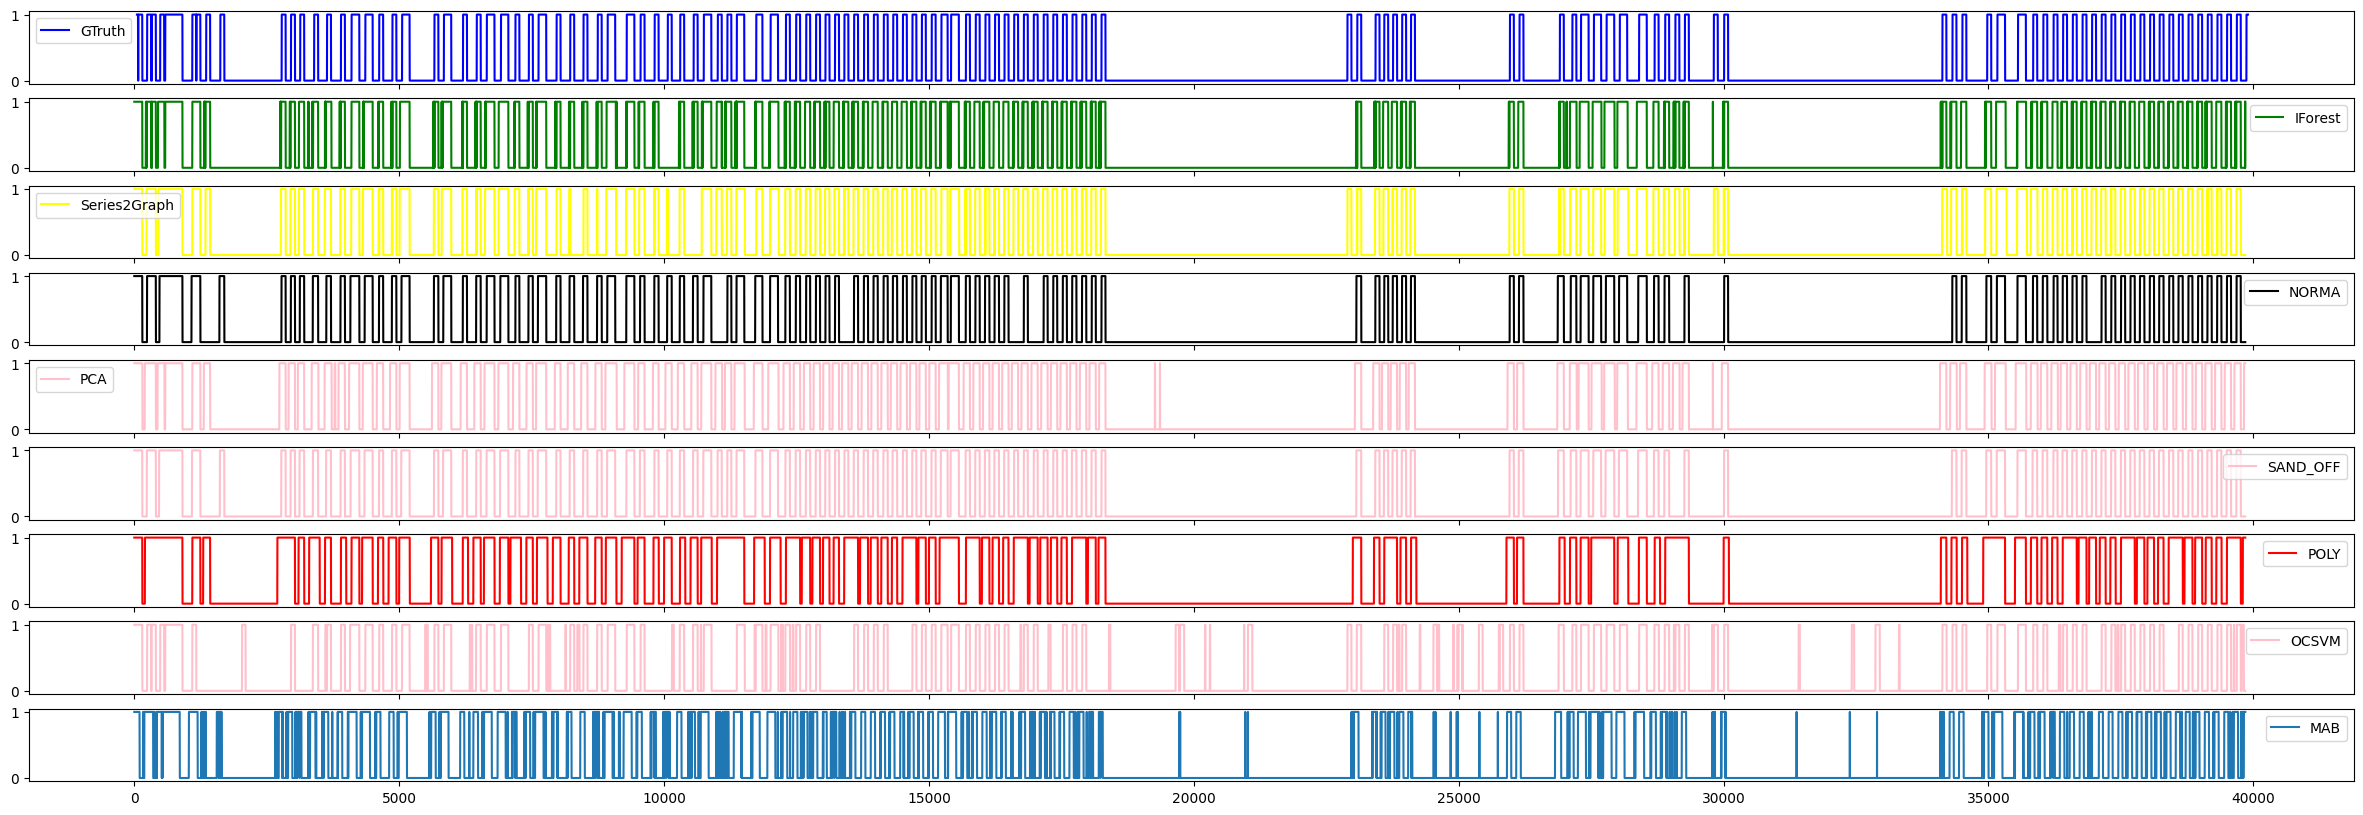

In [ ]:
import matplotlib.pyplot as plt


fig, (ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9) = plt.subplots(9, 1, sharex=True, figsize=(30, 10))
index = range(39848)
index_mab = range(50, 39848 + 50)

ax1.plot(index_mab, sample_gtruth, color='blue', label='GTruth')
ax7.plot(index, pred_list_test[5], color='red', label='POLY')
ax2.plot(index, pred_list_test[0], color = 'green', label = 'IForest')
ax3.plot(index, pred_list_test[1], color = 'yellow', label = 'Series2Graph')
ax4.plot(index, pred_list_test[2], color = 'black', label = 'NORMA')
ax5.plot(index, pred_list_test[3], color = 'pink', label = 'PCA')
ax6.plot(index, pred_list_test[4], color = 'pink', label = 'SAND_OFF')
ax8.plot(index, pred_list_test[6], color = 'pink', label = 'OCSVM')
#ax9.plot(index, pred_list_test[7], color = 'pink', label = 'AE')
ax9.plot(index, label_np, label = 'MAB')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax3.legend(loc='upper left')
ax4.legend(loc='upper right')
ax5.legend(loc='upper left')
ax6.legend(loc='upper right')
ax7.legend()
ax8.legend()
ax9.legend()
#ax10.legend()


plt.show()

### Random Agent

In [19]:
action_spec = test_environment.action_spec()
time_step_spec = test_environment.time_step_spec()
random_agent = RandomAgent(action_spec=action_spec, time_step_spec=time_step_spec)

In [20]:
aa = test_environment.reset()
action = random_agent.policy.action(aa)
aacctt = action.action.numpy()
type(aacctt[0])

numpy.int32

In [21]:
time_step = test_environment.reset()
random_act_list = []
random_score_list = []
random_label_list = []
random_action_list = []

aa = test_environment.reset()

for i in range(80000):

    action = random_agent.policy.action(aa)
    act = action.action.numpy()
    aa = test_environment.step(action.action)
    _, label, scr = test_env._apply_action(act[0])
    random_score_list.append(scr)
    random_label_list.append(label)
    random_action_list.append(act)

    print(i)

Step: 1, label: 0
0
Step: 2, label: 0
1
Step: 3, label: 0
2
Step: 4, label: 0
3
Step: 5, label: 0
4
Step: 6, label: 0
5
Step: 7, label: 0
6
Step: 8, label: 0
7
Step: 9, label: 0
8
Step: 10, label: 0
9
Step: 11, label: 0
10
Step: 12, label: 0
11
Step: 13, label: 0
12
Step: 14, label: 0
13
Step: 15, label: 0
14
Step: 16, label: 0
15
Step: 17, label: 0
16
Step: 18, label: 0
17
Step: 19, label: 0
18
Step: 20, label: 0
19
Step: 21, label: 0
20
Step: 22, label: 0
21
Step: 23, label: 0
22
Step: 24, label: 0
23
Step: 25, label: 0
24
Step: 26, label: 0
25
Step: 27, label: 0
26
Step: 28, label: 0
27
Step: 29, label: 0
28
Step: 30, label: 0
29
Step: 31, label: 0
30
Step: 32, label: 0
31
Step: 33, label: 0
32
Step: 34, label: 0
33
Step: 35, label: 0
34
Step: 36, label: 0
35
Step: 37, label: 0
36
Step: 38, label: 0
37
Step: 39, label: 0
38
Step: 40, label: 0
39
Step: 41, label: 0
40
Step: 42, label: 0
41
Step: 43, label: 0
42
Step: 44, label: 0
43
Step: 45, label: 0
44
Step: 46, label: 0
45
Step: 4

In [22]:
random_score_np = np.array(random_score_list)
random_label_np = np.array(random_label_list)

In [28]:
test_end = 35000
sample_gtruth = test_data['anomaly'].iloc[50:test_end+50]
gtruth_np = sample_gtruth.to_numpy()
print(gtruth_np.shape, random_score_np.shape)
rg_pr, rg_rc, rg_f1, rg_prauc, adjusted_y_pred = adjusted_precision_recall_f1_auc(gtruth_np, random_score_np[0:35000])
print(f'Random Agent Point Adjusted F1: {rg_f1:.4f}, Point Adjusted AUCpr: {rg_prauc:.4f}')

(35000,) (80000,)
Random Agent Point Adjusted F1: 0.9794, Point Adjusted AUCpr: 0.8676


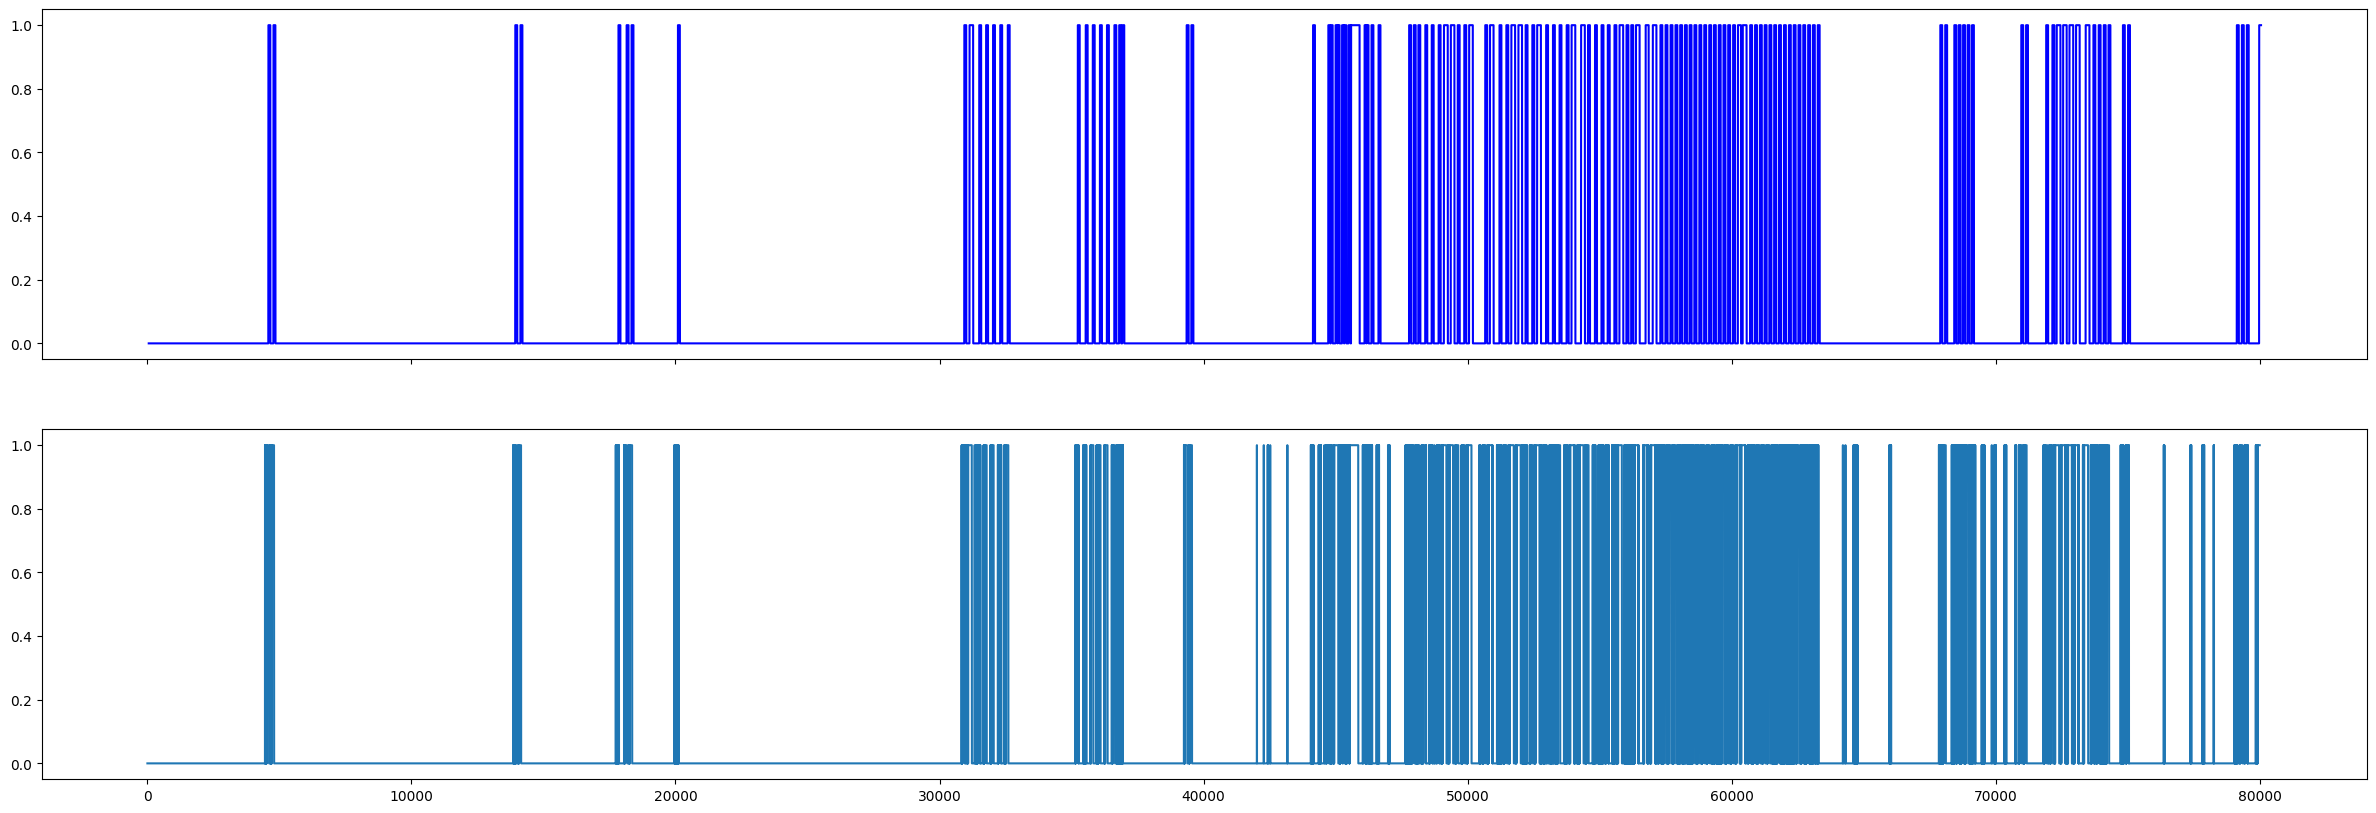

In [26]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(30, 10))
index = range(80000)
index_mab = range(50, 80050)

ax1.plot(index_mab, sample_gtruth, color='blue', label='GTruth')
ax2.plot(index, random_label_np, label = 'Random Agent')

In [27]:
act_np = np.array(random_action_list)
uniq_act, uniq_count = np.unique(act_np, return_counts=True)
print(uniq_act, uniq_count)

[0 1 2 3 4 5 6] [11581 11352 11500 11315 11527 11279 11446]


In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

prec = precision_score(gtruth_np, random_label_np[0:35000])
recall = recall_score(gtruth_np, random_label_np[0:35000])
f1 = f1_score(gtruth_np, random_label_np[0:35000])
rock = roc_auc_score(gtruth_np, random_label_np[0:35000])

print(f'Precision Score: {prec:.4f}  Recall: {recall:.4f}  f1_score: {f1:.4f} roc_auc: {rock}')

Precision Score: 0.7573  Recall: 0.9184  f1_score: 0.8301 roc_auc: 0.9540335893293346
